# Carrier injection based Micro-Ring Modulator

## Problem Parameters

In [ ]:
import numpy as np
import photonforge as pf
import tidy3d as td
from matplotlib import pyplot as plt
from tidy3d import web

Defining the Device Parameters Tidy3D example

In [ ]:
# modulator cross section parameters (um)
w_core_ring = 0.5            # Width of the ridge waveguide
w_core_bus  = 0.350          # width of the ridge for the bus
h_core = 0.26           # hight of the ridge
h_slab = 0.05           # hieght of the slab layer
h_side = h_slab         # silicon thickness under the metal contact
w_contact = 1           # width of the metal contact
x_side = 1.5            # Distance between center of rib and the metal contact
x_total = x_side + 1    # Half of the total width of the device
x_i = 0.25              # distance between rib center and start of doping (intrinsic region) 
x_p = 1.75              # Distance between rib center and P++
h_contact = h_core-h_slab # Hieght of the metal contact

# Oxide Parameters
TOX = 1     # Top Oxide Thickness
BOX = 1     # Bottom Oxide Thickness

# note that the height of the metal contact doesn't affect the results
# but devsim requires creating a region representing it
# in order to create a interface between the metal contact and modulator

# modulator doping concentrations (1/cm^3)
conc_p = 1e19
conc_pp = 5e19
conc_n = 1e19
conc_nn = 5e19
# note that concentrations in ++/-- are (conc_p + conc_pp) and (conc_n + conc_nn)

# photonic circuit geometric parameters (um)
y_length_in = 5
y_length_out = 5
ring_radius = 2.5
wg_spacing = 3.5

# effective infinity
effective_inf = 1e6

We will include here a model for undoped Silicon

In [ ]:
# let's define a material here for our Charge simulations
acceptors = []
donors = []

si_doped = td.MultiPhysicsMedium(
    optical=td.material_library["cSi"]["Li1993_293K"],
    charge=td.SemiconductorMedium(
        permittivity=11.1,
        N_c=td.ConstantEffectiveDOS(N=2.86e19),
        N_v=td.ConstantEffectiveDOS(N=3.1e19),
        E_g=td.ConstantEnergyBandGap(eg=1.11),
        mobility_n=td.ConstantMobilityModel(mu=400),
        mobility_p=td.ConstantMobilityModel(mu=200),
        R=[td.ShockleyReedHallRecombination(tau_n=1e-8, tau_p=1e-8)],
        N_a=acceptors,
        N_d=donors,
    ),
)

## Semiconductor medium

Before we can start the Charge simulation, let us create a semiconductor medium. Semiconductor mediums are constructed with the class [SemiconductorMedium](url=https://docs.flexcompute.com/projects/tidy3d/en/v2.8.0rc2/api/_autosummary/tidy3d.SemiconductorMedium.html#tidy3d.SemiconductorMedium). 

We will construct a basic PIN diode structure similar to the example. Even though this will be for a ring we will start the simulation assuming a straight section with a centered waveguide.

### Optic mediums
Since some of the structures will be reused in the optic simulations, let us also create the required mediums here.


In [ ]:
wvl_um = 1.54
freq0 = td.C_0 / wvl_um

si = si_doped.optical
n_si, k_si = si.nk_model(frequency=td.C_0 / wvl_um)
print("index = " + str(n_si))
print("Imaginary Index = " + str(k_si))

si_non_perturb = td.Medium.from_nk(n=n_si, k=k_si, freq=freq0)


sio2 = td.Medium(permittivity=1.444**2,
                 viz_spec=td.VisualizationSpec(facecolor="gray", alpha=0),
                 )

## Building the Ring Resonator

We are now ready to create the charge simulation. The first step is to create the waveguide structures. To do this, we define the following functions that encapsulate the necessary steps.

We will use PhotonForge’s layout capabilities. PhotonForge also provides a complete set of tools for photonic design automation, including PDK integration, parametric components, connectivity management, and technology definitions. You can check the many applications of this powerful tool [here](https://docs.flexcompute.com/projects/photonforge/en/latest/examples.html).

The `make_waveguide` function is a generic function that creates a tapered waveguide with initial width `wg_width_0` and final width `wg_width_1`. This is easily achieved using [pf.Path](https://docs.flexcompute.com/projects/photonforge/en/latest/_autosummary/photonforge.Path.html) and `pf.Path.segment`.

In [ ]:

# parameters
wg_width      = w_core_bus
wg_thickness  = h_core - h_slab          # ridge above the slab
z0            = h_slab                   # ridge sits on top of the slab
y_start       = 0.0
y_end         = y_length_in + y_length_out
x_center      = 0.0

# four corner vertices of the straight rib (running along y)
hw = wg_width / 2.0
vertices = [
    (x_center - hw, y_start),
    (x_center + hw, y_start),
    (x_center + hw, y_end),
    (x_center - hw, y_end),
]

# geometry -> structure -> scene
geometry  = td.PolySlab(vertices=vertices, axis=2,
                        slab_bounds=(z0, z0 + wg_thickness))
bus       = td.Structure(geometry=geometry, medium=si)
scene     = td.Scene(structures=[bus], medium=sio2)

'''
scene.plot_3d()

plt.tight_layout()
plt.show()
'''


In [ ]:
# footprint shared by all planar layers
fp_xsize = 10.0
fp_ysize = y_end + 5.0
fp_xc    = 0.0
fp_yc    = y_end / 2.0

# BOX (oxide below the slab):  z from -BOX to 0
box_layer = td.Structure(
    geometry=td.Box(center=(fp_xc, fp_yc, -BOX/2),
                    size=(fp_xsize, fp_ysize, BOX)),
    medium=sio2,
)

# Si slab:  z from 0 to h_slab
slab_layer = td.Structure(
    geometry=td.Box(center=(fp_xc, fp_yc, h_slab/2),
                    size=(fp_xsize, fp_ysize, h_slab)),
    medium=si,
)

# oxide filling the ridge layer (gets overridden by the Si bus)
ridge_oxide = td.Structure(
    geometry=td.Box(center=(fp_xc, fp_yc, h_slab + (h_core-h_slab)/2),
                    size=(fp_xsize, fp_ysize, h_core - h_slab)),
    medium=sio2,
)

# TOX (oxide above the ridge):  z from h_core to h_core + TOX
tox_layer = td.Structure(
    geometry=td.Box(center=(fp_xc, fp_yc, h_core + TOX/2),
                    size=(fp_xsize, fp_ysize, TOX)),
    medium=sio2,
)

# rebuild the scene with everything
scene = td.Scene(
    structures=[box_layer, slab_layer, ridge_oxide, bus, tox_layer],
    medium=td.Medium(permittivity=1.0),
)


scene.plot_3d()

plt.tight_layout()
plt.show()


### Rib Waveguide Geometry (Basic Charge Simulation)
This is a straight waveguide section. we will test the phase and amplitude effects for a bent mode in a straight waveguide. this will give us an approximation of the effects of the Micro Ring Resonator 

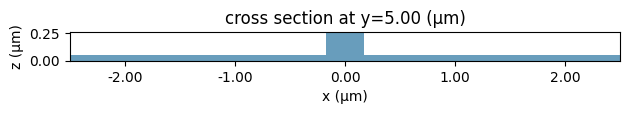

In [323]:
# parameters
wg_width      = w_core_bus
wg_thickness  = h_core - h_slab          # ridge above the slab
z0            = h_slab                   # ridge sits on top of the slab
y_start       = 0.0
y_end         = y_length_in + y_length_out
x_center      = 0.0

# four corner vertices of the straight rib (running along y)
hw = wg_width / 2.0
vertices = [
    (x_center - hw, y_start),
    (x_center + hw, y_start),
    (x_center + hw, y_end),
    (x_center - hw, y_end),
]

vertices_slab = [
    (x_center - x_total, y_start),
    (x_center + x_total, y_start),
    (x_center + x_total, y_end),
    (x_center - x_total, y_end),
]

# geometry -> structure -> scene
geometry  = td.PolySlab(vertices=vertices, axis=2,
                        slab_bounds=(z0, z0 + wg_thickness))
geometry2 = td.PolySlab(vertices=vertices_slab, axis=2,
                        slab_bounds=(z0 - h_slab, z0))
PIN       = td.Structure(geometry=geometry+geometry2, medium=si_doped)
scene     = td.Scene(structures=[PIN], medium=sio2)

#scene.plot_3d()
scene.plot(y = 5)

#fig, ax = plt.subplots()
#scene.plot_eps(y=5, ax=ax)

plt.tight_layout()
plt.show()

### Charge Simulation


In [ ]:
acceptors = []
donors = []

#print(wg_spacing)

# Unlike the example we will center the PIN region

acceptors.append(
    td.ConstantDoping.from_bounds(
        rmin=[-x_total, -effective_inf, 0],
        rmax=[-x_p, effective_inf, h_core],
        concentration=conc_pp,
    )
)
acceptors.append(
    td.ConstantDoping.from_bounds(
        rmin=[-x_total, -effective_inf, 0],
        rmax=[-x_i, effective_inf, h_core],
        concentration=conc_p,
    )
)

donors.append(
    td.ConstantDoping.from_bounds(
        rmin=[x_p, -effective_inf, 0],
        rmax=[x_total, effective_inf, h_core],
        concentration=conc_nn,
    )
)
donors.append(
    td.ConstantDoping.from_bounds(
        rmin=[x_i, -effective_inf, 0],
        rmax=[x_total, effective_inf, h_core],
        concentration=conc_n,
    )
)

In [ ]:
# let's define a material here for our Charge simulations
si_doped = td.MultiPhysicsMedium(
    optical=td.material_library["cSi"]["Li1993_293K"],
    charge=td.SemiconductorMedium(
        permittivity=11.1,
        N_c=td.ConstantEffectiveDOS(N=2.86e19),
        N_v=td.ConstantEffectiveDOS(N=3.1e19),
        E_g=td.ConstantEnergyBandGap(eg=1.11),
        mobility_n=td.ConstantMobilityModel(mu=400),
        mobility_p=td.ConstantMobilityModel(mu=200),
        R=[td.ShockleyReedHallRecombination(tau_n=1e-8, tau_p=1e-8)],
        N_a=acceptors,
        N_d=donors,
    ),
)

# 1) Built-in dispersive Johnson-Christy model (best)
cu_optical = td.material_library["Cu"]["JohnsonChristy1972"]

# auxiliary materials we use to define BCs
aux_medium = td.MultiPhysicsMedium(
    optical=cu_optical,
    charge=td.ChargeConductorMedium(conductivity=1), name="aux_medium"
)


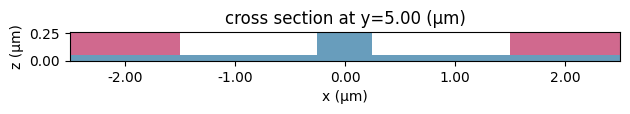

In [397]:
# parameters
wg_width      = w_core_ring              # this is now the ring width for the modulator section
wg_thickness  = h_core - h_slab          # ridge above the slab
z0            = h_slab                   # ridge sits on top of the slab
y_start       = 0.0
y_end         = y_length_in + y_length_out
x_center      = 0.0

# four corner vertices of the straight rib (running along y)
hw = wg_width / 2.0
vertices = [
    (x_center - hw, y_start),
    (x_center + hw, y_start),
    (x_center + hw, y_end),
    (x_center - hw, y_end),
]

vertices_slab = [
    (x_center - x_total, y_start),
    (x_center + x_total, y_start),
    (x_center + x_total, y_end),
    (x_center - x_total, y_end),
]

# geometry -> structure -> scene
geometry  = td.PolySlab(vertices=vertices, axis=2,
                        slab_bounds=(z0, z0 + wg_thickness))
geometry2 = td.PolySlab(vertices=vertices_slab, axis=2,
                        slab_bounds=(z0 - h_slab, z0))
PIN       = td.Structure(geometry=geometry+geometry2, medium=si_doped)

# create a couple structs to define the contacts
contact_p = td.Structure(
    geometry=td.Box(
        center=(- x_total + w_contact / 2, y_end/2, h_side + h_contact / 2),
        size=(w_contact, y_end-y_start, h_contact),
    ),
    medium=aux_medium,
    name="contact_p",
)


contact_n = td.Structure(
    geometry=td.Box(
        center=(x_total - w_contact / 2, y_end/2, h_side + h_contact / 2),
        size=(w_contact, y_end-y_start, h_contact),
    ),
    medium=aux_medium,
    name="contact_n",
)


scene_charge     = td.Scene(structures=[PIN, contact_p, contact_n], medium=sio2)
#scene_charge.plot_3d()
scene_charge.plot(y = 5)


plt.tight_layout()
plt.show()

In [ ]:
scene_charge.plot_structures_property(y=5, property="doping")
plt.show()

Boundary conditions
Let's define forward bias values up to 1.2 V with a step of 0.1 V.

In [ ]:
# create BCs
voltages = list(np.arange(13) * 0.1)

bc_v1 = td.HeatChargeBoundarySpec(
    condition=td.VoltageBC(source=td.DCVoltageSource(voltage=voltages)),
    placement=td.StructureBoundary(structure=contact_p.name),
)

bc_v2 = td.HeatChargeBoundarySpec(
    condition=td.VoltageBC(source=td.DCVoltageSource(voltage=0)),
    placement=td.StructureBoundary(structure=contact_n.name),
)

boundary_conditions = [bc_v1, bc_v2]

Defining Charge monitors and Capacitance monitors

In [ ]:
charge_mnt = td.SteadyFreeCarrierMonitor(
    center=(0, y_end/2, h_slab/2),
    size=(effective_inf, 0, effective_inf),
    name="charge_mnt",
    unstructured=True,
)

cap_mnt = td.SteadyCapacitanceMonitor(
    center=(0, y_end/2, h_slab/2),
    size=(effective_inf, 0, effective_inf),     # 2D slice through the junction
    name="cap",
    unstructured=True,
)

efield_mnt = td.SteadyElectricFieldMonitor(
    center=(0, y_end/2, h_slab/2),
    size=(effective_inf, 0, effective_inf),
    name="efield",
    unstructured=True,
)

Charge simulation object

In [ ]:
convergence_settings = td.ChargeToleranceSpec(rel_tol=1e-5, abs_tol=5e10, max_iters=400)

analysis_type = td.IsothermalSteadyChargeDCAnalysis(
    temperature=300, tolerance_settings=convergence_settings, convergence_dv=0.1
)

res = 0.005
mesh = td.UniformUnstructuredGrid(dl=res, relative_min_dl=0)


We now have all the required elements to define a Charge simulation object. Note that the simulation has 0 size in the $x$ direction. With this, we'll make sure that the simulation is 2D even if the structures themselves are not.

In [ ]:
charge_sim = td.HeatChargeSimulation(
    sources=[],
    monitors=[charge_mnt, cap_mnt, efield_mnt],
    analysis_spec=analysis_type,
    center=(0, y_end/2, h_slab/2),
    size=(2 * x_total, 0, h_side + h_contact),
    structures=scene_charge.structures,
    medium=scene_charge.medium,
    boundary_spec=boundary_conditions,
    grid_spec=mesh,
    symmetry=(0, 0, 0),
)


We can also plot here the simulation and some properties. In the properties plot, as well as the conductivity (which is invisible since the only conducting structures are the BC auxiliary ones) we can see the boundary conditions in blue and orange.

In [ ]:
# plot simulation
fig, ax = plt.subplots(1, 2, figsize=(10, 15))
charge_sim.plot(y=5, ax=ax[0])
charge_sim.plot_property(y=5, property="electric_conductivity", ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
charge_data = web.run(charge_sim, task_name="mzi_pin", path="E:\WorkFiles\Projects\Portfolio Projects\SiPh MRM\Charge Simulations\MRM\charge_mrm_pin.hdf5")

### Electrostatic Field

['charge_mnt', 'cap', 'efield']


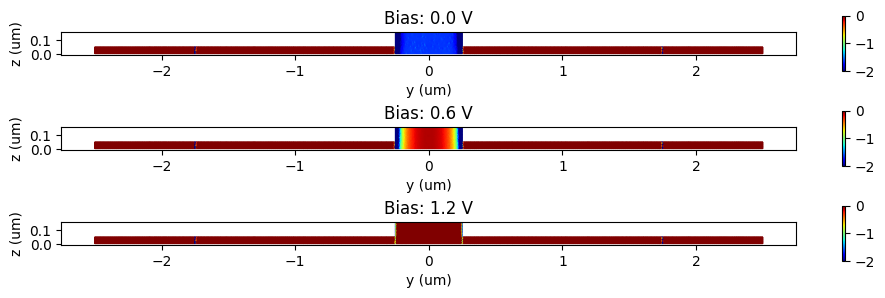

In [327]:
_, ax = plt.subplots(3, 1, figsize=(10, 3))
print(list(charge_data.monitor_data.keys()))
#print(voltages)
vmin, vmax = -2, 0

for ind, volt in enumerate([voltages[0], voltages[6],voltages[-1]]):
    charge_data["efield"].E.sel(y=5, axis = 0, voltage=volt).plot(ax=ax[int(ind)], cmap = "jet", vmin = vmin, vmax = vmax, grid = False)
    ax[ind].set_title(f"Bias: {volt:1.1f} V")
    ax[ind].set_xlabel("y (um)")
    ax[ind].set_ylabel("z (um)")


plt.tight_layout()
plt.show()

Junction Capacitance

In [ ]:
'''
da = charge_data["cap"].electron_capacitance
print(da.dims)
print(da.coords)
'''

fig, ax = plt.subplots()
charge_data["cap"].electron_capacitance.plot(ax=ax, label="electron C")
charge_data["cap"].hole_capacitance.plot(ax=ax, label="hole C")
ax.set_xlabel("Bias (V)"); ax.set_ylabel("C [fF/um]")
ax.legend()


plt.tight_layout()
plt.show()

print(charge_data["cap"].electron_capacitance.values)

Carrier Distribution

Let's visualize the electron distributions for zero and 1.2 V biases.

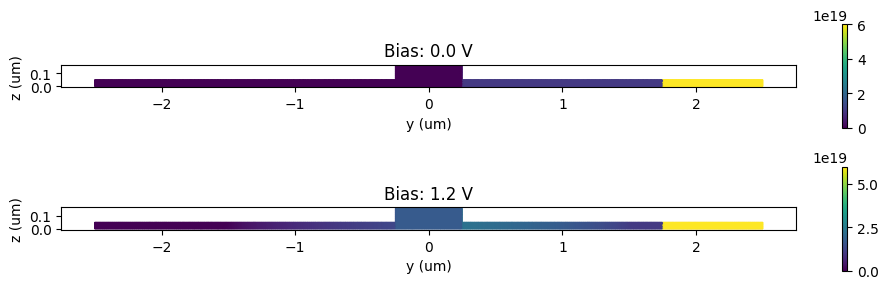

In [364]:
_, ax = plt.subplots(2, 1, figsize=(10, 3))

for ind, volt in enumerate([voltages[0], voltages[-1]]):
    charge_data["charge_mnt"].electrons.sel(y=5, voltage=volt).plot(ax=ax[ind], grid = False)
    ax[ind].set_title(f"Bias: {volt:1.1f} V")
    ax[ind].set_xlabel("y (um)")
    ax[ind].set_ylabel("z (um)")

plt.tight_layout()
plt.show()

## Optic Simulations

Having obtained free carrier solutions in the modulator cross section we can now turn to setting up optic simulation that will use these results.

We will use empiric relationships presented in [M. Nedeljkovic, R. Soref and G. Z. Mashanovich, "Free-Carrier Electrorefraction and Electroabsorption Modulation Predictions for Silicon Over the 1–14-  μm  Infrared Wavelength Range," IEEE Photonics Journal, vol. 3, no. 6, pp. 1171-1180, Dec. 2011](https://doi.org/10.1109/JPHOT.2011.2171930), that state that changes in $n$ and $k$ of Si can be described by formulas
$$ - \Delta n = \frac{dn}{dN_e}(\lambda) (\Delta N_e)^{\alpha(\lambda)} + \frac{dn}{dN_h}(\lambda) (\Delta N_h)^{\beta(\lambda)}$$
$$ \Delta \left( \frac{4 \pi k}{\lambda} \right) = \frac{dk}{dN_e}(\lambda) (\Delta N_e)^{\gamma(\lambda)} + \frac{dk}{dN_h}(\lambda) (\Delta N_h)^{\delta(\lambda)}$$
where $\Delta N_e$ and $\Delta N_h$ are electron and hole densities, and parameters have the following values for wavelength of 1.55 $\mu$m:

| $\lambda$ | $\frac{dn}{dN_e}$ | $\alpha$ | $\frac{dn}{dN_h}$ | $\beta$ | $\frac{dk}{dN_e}$ | $\gamma$ | $\frac{dk}{dN_h}$ | $\delta$ |
| --------- | ----------------- | ------- | ------------------ | ------- | ----------------- | -------- | ----------------- | -------- |
| $1.55$ | $5.40 \times 10^{-22}$ | $1.011$ | $1.53 \times 10^{-18}$ | $0.838$ | $8.88 \times 10^{-21}$ | $1.167$ | $5.84 \times 10^{-20}$ | $1.109$ | 

In [387]:
ne_coeff = -5.4e-22
ne_pow = 1.011

nh_coeff = -1.53e-18
nh_pow = 0.838

k_factor = wvl_um * 1e-4 / 4 / np.pi  # factor for conversion from absorption coefficient into k

ke_coeff = k_factor * 8.88e-21
ke_pow = 1.167

kh_coeff = k_factor * 5.84e-20
kh_pow = 1.109

Given the nonlinear character of these dependencies we will incorporate them as sampled function on a rectangular grid formed by electron and hole density values. Specifically, we will sample the given $n$ and $k$ dependencies in the electron and hole density ranges up to $10^{20}$ 1/$\text{cm}^3$.

In [388]:
max_electron_exp = np.ceil(
    np.log10(charge_data["charge_mnt"].electrons.sel(x=0, y=5, z=0.1, method="nearest").values.max())
)
max_holes_exp = np.ceil(
    np.log10(charge_data["charge_mnt"].holes.sel(x=0, y=5, z=0.1, method="nearest").values.max())
)

print(f"Max electron density exponent: {max_electron_exp:.0f}")
print(f"Max hole density exponent: {max_holes_exp:.0f}")

Max electron density exponent: 20
Max hole density exponent: 20


In [389]:
Ne_range = np.concatenate(([0], np.logspace(15, max_electron_exp, 20)))
Nh_range = np.concatenate(([0], np.logspace(15, max_holes_exp, 21)))

Ne_mesh, Nh_mesh = np.meshgrid(Ne_range, Nh_range, indexing="ij")

dn_mesh = ne_coeff * Ne_mesh**ne_pow + nh_coeff * Nh_mesh**nh_pow
dk_mesh = ke_coeff * Ne_mesh**ke_pow + kh_coeff * Nh_mesh**kh_pow

Now we convert sampled values of $n$ and $k$ into permittivity $\varepsilon$ and conductivity $\sigma$ values, and assemble a non-dispersive medium with perturbations (`PerturbationMedium`).

In [390]:
dn_data = td.ChargeDataArray(dn_mesh, coords=dict(n=Ne_range, p=Nh_range))
dk_data = td.ChargeDataArray(dk_mesh, coords=dict(n=Ne_range, p=Nh_range))

n_si_charge = td.CustomChargePerturbation(perturbation_values=dn_data)
k_si_charge = td.CustomChargePerturbation(perturbation_values=dk_data)

n_si_perturbation = td.ParameterPerturbation(
    charge=n_si_charge,
)

k_si_perturbation = td.ParameterPerturbation(
    charge=k_si_charge,
)

si_perturb = td.PerturbationMedium.from_unperturbed(
    medium=si_non_perturb,
    perturbation_spec=td.IndexPerturbation(
        delta_n=n_si_perturbation,
        delta_k=k_si_perturbation,
        freq=freq0,
    ),
)

### Setup Simulation for Optical Mode

We will refere to the Scene we generated for the doped rib waveguide
1. Remake waveguide with the perturbed silicon

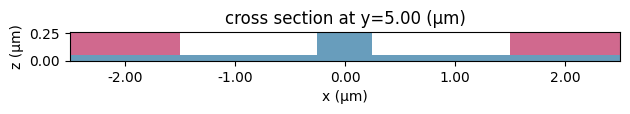

In [398]:
# parameters
wg_width      = w_core_ring              # this is now the ring width for the modulator section
wg_thickness  = h_core - h_slab          # ridge above the slab
z0            = h_slab                   # ridge sits on top of the slab
y_start       = 0.0
y_end         = y_length_in + y_length_out
x_center      = 0.0

# four corner vertices of the straight rib (running along y)
hw = wg_width / 2.0
vertices = [
    (x_center - hw, y_start),
    (x_center + hw, y_start),
    (x_center + hw, y_end),
    (x_center - hw, y_end),
]

vertices_slab = [
    (x_center - x_total, y_start),
    (x_center + x_total, y_start),
    (x_center + x_total, y_end),
    (x_center - x_total, y_end),
]

# geometry -> structure -> scene
geometry  = td.PolySlab(vertices=vertices, axis=2,
                        slab_bounds=(z0, z0 + wg_thickness))
geometry2 = td.PolySlab(vertices=vertices_slab, axis=2,
                        slab_bounds=(z0 - h_slab, z0))
PIN       = td.Structure(geometry=geometry+geometry2, medium=si_perturb)

# create a couple structs to define the contacts
contact_p = td.Structure(
    geometry=td.Box(
        center=(- x_total + w_contact / 2, y_end/2, h_side + h_contact / 2),
        size=(w_contact, y_end-y_start, h_contact),
    ),
    medium=aux_medium,
    name="contact_p",
)


contact_n = td.Structure(
    geometry=td.Box(
        center=(x_total - w_contact / 2, y_end/2, h_side + h_contact / 2),
        size=(w_contact, y_end-y_start, h_contact),
    ),
    medium=aux_medium,
    name="contact_n",
)


scene_charge     = td.Scene(structures=[PIN, contact_p, contact_n], medium=sio2)
#scene_charge.plot_3d()
scene_charge.plot(y = 5)


plt.tight_layout()
plt.show()

In [409]:
fwidth = freq0 / 5
freqs = np.linspace(freq0 - fwidth / 10, freq0 + fwidth / 10, 201)
buffer = 2

src = td.ModeSource(
    center=(0, y_end/2, h_slab/2),
    size=(2 * x_total, 0, h_side + h_contact + buffer),
    direction="+",
    mode_index=0,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
)

In [400]:

sim_size = (2 * x_total, y_end-y_start, h_side + h_contact + buffer)


sim = td.Simulation.from_scene(
    scene_charge,
    center=scene_charge.center,
    size=sim_size,
    sources=[src],
    monitors=[],
    run_time=6e-11,
)


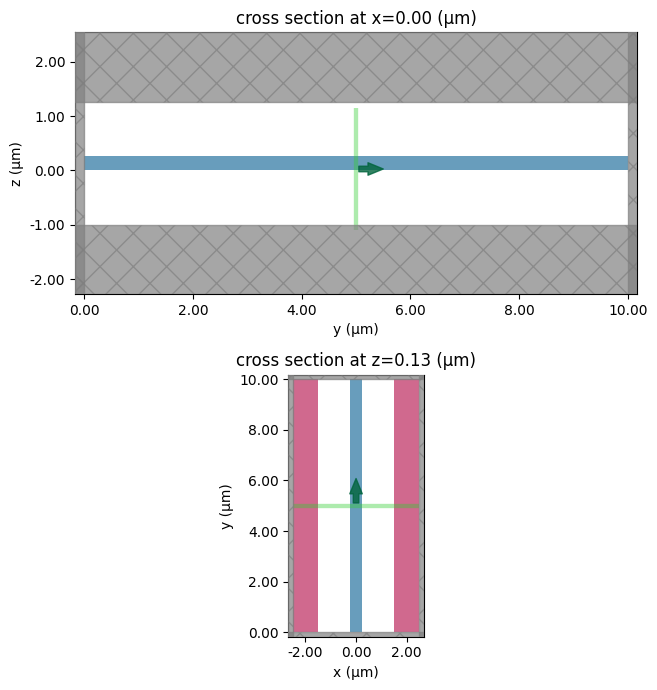

In [401]:
_, ax = plt.subplots(2, 1, figsize=(15, 7))
sim.plot(x=sim.center[0], ax=ax[0])
sim.plot(z=sim.center[2], ax=ax[1])

plt.tight_layout()
plt.show()

### Applying Carrier Distributions
At this point we have created an optic simulation that contains materials with charge perturbation models, however no electron and hole distributions have been provided to it. That is, when we submit such a simulation for solving, all mediums with perturbation models will be considered as regular materials with no perturbations applied. In our case, this corresponds to the case of undoped materials.

To obtain simulations in which perturbation models are sampled against provided carrier densities one can use a convenience method `perturbed_mediums_copy()`.

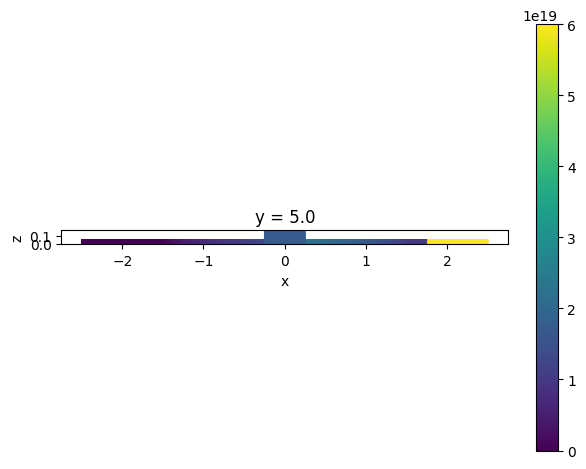

In [402]:
e_data = charge_data["charge_mnt"].electrons.sel(y=5,voltage=voltages[12]).plot(grid=False)

23:25:08 Pacific Daylight Time WARNING: Provided 'electron_density' does not    
                               fully cover structures[0].                       

                               WARNING: Provided 'hole_density' does not fully  
                               cover structures[0].                             

                               WARNING: Provided 'electron_density' does not    
                               fully cover structures[0].                       

                               WARNING: Provided 'hole_density' does not fully  
                               cover structures[0].                             

                               WARNING: Provided 'electron_density' does not    
                               fully cover structures[0].                       

...

                               WARNING: Provided 'hole_density' does not fully  
                               cover structures[0].                             

23:25:11 Pacific Daylight Time WARNING: Provided 'electron_density' does not    
                               fully cover structures[0].                       

                               WARNING: Provided 'hole_density' does not fully  
                               cover structures[0].                             

                               WARNING: Provided 'electron_density' does not    
                               fully cover structures[0].                       

                               WARNING: Provided 'hole_density' does not fully  
                               cover structures[0].                             

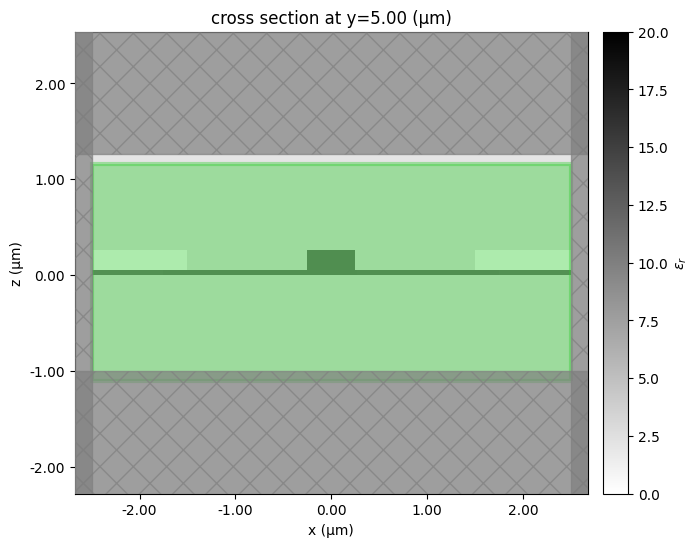

<class 'tidy3d.components.medium.CustomMedium'>


In [403]:

def apply_charge(charge_data):
    perturbed_sims = []
    for n, v in enumerate(charge_data["charge_mnt"].electrons.values.voltage.data):
        e_data = charge_data["charge_mnt"].electrons.sel(voltage=v)
        h_data = charge_data["charge_mnt"].holes.sel(voltage=v)
        perturbed_sims.append(
            sim.perturbed_mediums_copy(
                electron_density=e_data,
                hole_density=h_data,
            )
        )
    return perturbed_sims


perturbed_sims = apply_charge(charge_data)

fig, ax = plt.subplots(figsize=(8, 6))
vmin = 0; vmax = 20
perturbed_sims[10].plot_eps(y=sim.center[1],ax = ax, eps_lim=(vmin,vmax))
plt.show()
print(type(perturbed_sims[0].structures[0].medium))

The difference in the permittivity values in the modulator cross-section compared to the undoped case can be visualized as follows.

<xarray.DataArray ()> Size: 8B
array(139.93261576)
<xarray.DataArray ()> Size: 8B
array(274.45812526)


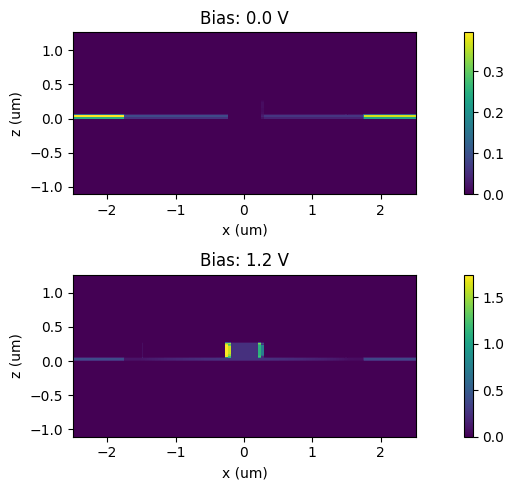

In [404]:
_, ax = plt.subplots(2, 1, figsize=(10, 5))

sampling_region = td.Box( center=(0, y_end/2, h_slab/2), size=(2 * x_total, 0, h_side + h_contact+buffer))
eps_undoped = sim.epsilon(box=sampling_region).isel(y=0, drop=True)
#print(eps_doped.shape)
#print(eps_undoped.shape)

for ax_ind, ind in enumerate([0, 12]):
    eps_doped = perturbed_sims[ind].epsilon(box=sampling_region).isel(y=0, drop=True)
    eps_doped = eps_doped.interp(x=eps_undoped.x, z=eps_undoped.z)
    eps_diff = np.abs(np.real(eps_doped - eps_undoped))
    print(np.sum(eps_diff))
    eps_diff.plot(x="x", ax=ax[ax_ind])

    ax[ax_ind].set_aspect("equal")
    ax[ax_ind].set_title(f"Bias: {voltages[ind]:1.1f} V")
    ax[ax_ind].set_xlabel("x (um)")
    ax[ax_ind].set_ylabel("z (um)")

plt.tight_layout()
plt.show()

### Waveguide Mode Analysis

Before proceeding to full-wave simulations one can investigate the influence of applied voltage on the propagation index of waveguide modes in the modulator.

In [405]:
from tidy3d.plugins.mode import ModeSolver

Let us define a plane for which waveguide modes will be calculated.

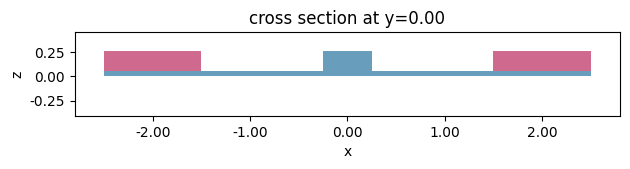

In [406]:
mode_plane = td.Box(    center=(0, y_end/2, h_slab/2),
                        size=(2 * x_total, 0, h_side + h_contact),)

# visualize
ax = scene_charge.plot(y=mode_plane.center[0])
mode_plane.plot(y=mode_plane.center[0], ax=ax, alpha=0.5)

plt.show()

Create a mode solver specification for each carrier distribution. We will consider only the first mode at 11 different frequencies. Also, given that the anticipated changes are small, double precision is turned on for mode solving.

In [410]:
mode_solvers = {}
for n, psim in enumerate(perturbed_sims):
    ms = ModeSolver(
        simulation=psim,
        plane=mode_plane,
        freqs=np.linspace(freqs[0], freqs[-1], 11),
        mode_spec=td.ModeSpec(num_modes=1, precision="double"),
    )
    mode_solvers[f"v={voltages[n]}"] = ms

Perform calculation on our servers. Note that since the associated simulation objects contain custom medium data, they are automatically reduced to the mode solver plane for optimizing uploading/downloading data. Setting `reduce_simulation=True` will silence the associated warning.

In [412]:
batch = web.Batch(simulations=mode_solvers, reduce_simulation=True)
ms_data = batch.run()

OSError: [Errno 22] Unable to synchronously create file (unable to open file: name = 'batch.hdf5', errno = 22, error message = 'Invalid argument', flags = 13, o_flags = 302)

Let us extract the effective propagation index for the central frequency and visualize its dependence on applied voltage. As expected, increasing the applied voltage results in a more pronounced change in the propagation index and, at the same time, in larger losses in the waveguide.

In [ ]:
n_eff_freq0 = [md.n_complex.sel(f=freq0, mode_index=0).values for _, md in ms_data.items()]

_, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(voltages, np.real(n_eff_freq0), ".-")

ax[0].set_xlabel("Bias (V)")
ax[0].set_ylabel("Re[$n_{eff}$]")

ax[1].plot(voltages, np.imag(n_eff_freq0), ".-")

ax[1].set_xlabel("Bias (V)")
ax[1].set_ylabel("Im[$n_{eff}$]")

plt.show()

Using the obtained propagation index values we can compute the associated phase change and loss over the PIN section of the modulator at the central wavelength of 1.55 um. From this information we can estimate the bias $V_\pi$ required for a phase shift of $\pi$ to be around 0.95 V. In [Zhou Liang et al 2011 Chinese Phys. Lett. 28 074202](https://doi.org/10.1088/0256-307X/28/7/074202) the value of 1.15 V was obtained for a similar experimental setup.

In [ ]:
phase_shift = 2 * np.pi / wvl_um * (np.real(n_eff_freq0) - np.real(n_eff_freq0[0])) * pin_length
intensity = np.exp(-4 * np.pi * np.imag(n_eff_freq0) * pin_length / wvl_um)

_, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(voltages, phase_shift / np.pi, ".-")
ax[0].axhline(y=-1, color="k", linestyle="--")

ax[0].set_xlabel("Bias (V)")
ax[0].set_ylabel(r"Phase shift ($\pi$)")

ax[1].plot(voltages, 10 * np.log10(intensity), ".-")

ax[1].set_xlabel("Bias (V)")
ax[1].set_ylabel("Output power (dB)")

plt.show()